# Ti64 Statistical Modelling
## Modelling Beta approach curves from literature to produce a beta volume fraction calculator
### Rory Atlasi Barker, Guy Bowker

This notebook can be used to filter beta-approach curves for Ti64 volume fraction measurments from literature.
Change the temperature range, microstructure, strain rate, or other options in the example cells at the bottom to plot the corresponding curves for those conditions.
Functions can be found next to this notebook in `utils.py`.
To add data from a paper, simply create a new file in this repository named after the paper authors as shown containing the data as a `.csv` file.
Then add the papers metadata and relative filepath to the `beta-approach_curves.yaml` file.

In [1]:
# Import libraries and funcs from utils.py

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
from scipy.optimize import curve_fit
import sys
import yaml
from yaml.loader import FullLoader
from yaml.loader import SafeLoader

path = os.path.abspath("Beta-approach_curves/")
sys.path.append(path)
from beta_approach_curve_utils import load_yml
from beta_approach_curve_utils import sort_curve
from beta_approach_curve_utils import curve_filter
from beta_approach_curve_utils import curve_plotter


Load `beta-approach_curves.yml` file, read in data for each paper as pandas dataframe, and show all papers:

In [2]:

# define alloy which you want curve data for
alloy = 'Ti-6Al-4V'

# load metadata from yml file
database = load_yml(alloy)



Experiments: 
dict_keys(['Diamond_2022'])

Papers: 
dict_keys(['Sesha_2000', 'Semiatin_2002', 'Tamiri_2005', 'Reddy_2006', 'Motyka_2012', 'Villa_2019', 'He_2020', 'Janda_2022'])


## Filter the data

Filter out and plot only the desired beta approach curves from the literature data.

Save paper metadata and beta-approach curves to a dictionary `filtered_database`, which can be saved to a `.pkl` file to be plotted alongside other data in a different code. The `filtered_database` dictionary can be easily parsed to plot all the data on the same plot.

In [3]:

# Define desired parameters:
parameters = {                                  # USER OPTIONS GUIDE
              'heating_rate' : 'any',            # float in C/s or 'any' as str
              'Strain_rate_s-1' : 'any',         # float in /s or 'any' as str
              'In_situ_heating' : 'any',         # 'induction', 'gleeble' or 'any' as str
    
              'exclusions' : ['Sesha_2000']    # dataset keys to exclude (empty if none)
             }


# Filter beta approach curve data by def params:
filtered_databasebase = curve_filter(database, parameters);


Chosen heating rate:any

Including Diamond_2022
Sesha_2000 IN EXCLUSIONS LIST.
Including Semiatin_2002
Including Semiatin_2002
Including Semiatin_2002
Including Tamiri_2005
Including Reddy_2006
Including Motyka_2012
Including Villa_2019
Including Villa_2019
Including Villa_2019
Including He_2020
Including Janda_2022


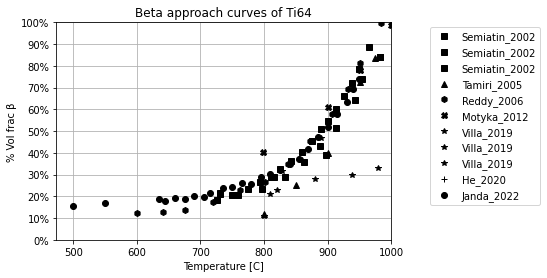

In [4]:
%matplotlib inline

curve_plotter(filtered_databasebase)

pickle.dump(filtered_databasebase, open('beta-approach_curves.pkl', 'wb'))

First, estimate a model relationship between temperature T and volume fraction of beta phase.
An exponential function is expected to fit the trend of beta volume fraction with increasing temperature.
Here is where the choice of data to include in the previous step becomes important, because some data is more unreliable, has less datapoints, etc.

$\Large{β_{volfrac\%} = a + b^{c(T+d)}}$

Ranges for each term have been determined via application of the function to a variety of beta approach datasets:

$-30<a<20$

$1.003<b<1.005$

$1<c<3$

$-610<d<-30$

In [5]:
def testfunc(T, a, b, c, d):
    """Model exponential function for beta approach curves.
    Comments:
       a appears to be a correction term in the same units as VF (unitless)
       b is the term to which the exponential including T is raised
       c is multiplied by the temperature after some correction d
       d is a addition correction to T in the same units as T (celsius)
    """
    return a + (b)**(c*(T+d))

Next, use this model curve to predict/extrapolate between measured datapoints for each curve in the literature.
Plot the model curves for each dataset and see the maximum and minimum bounds for any given temperature or volume fraction of beta.
We can also predict the beta-transus temperature for each dataset.
Note including only papers with high-temperature ranges of beta volume fraction measurments introduces much more uncertainty at lower temperature, and vice versa.


To get a definitive answer to the question "what is the beta volume fraction at temperature $X$?" the model curves need to be combined.
One model beta approach curve weighted by the contributions of many measured beta approach curves is the most reliable to answer this question.
We have `T` and `betavolfrac` values from $500C$ to $1000C$ in $1C$ steps for each dataset -
we can mean over these values to get a mean beta approach curve:


Diamond_2022
Curve: 1
a:-25.30242342600616	b:1.0043272398151053	c: 1.1628249273259157	d: -30.471548815576565
Found beta transus!: T=992C

Semiatin_2002
Curve: 1
a:6.77739659875367	b:1.0043494251260492	c: 1.9166301569529465	d: -435.54296888638805
Found beta transus!: T=981C
Curve: 2
a:10.969512951783704	b:1.0038577209576867	c: 2.3356773660181562	d: -503.48161781470276
Found beta transus!: T=1003C
Curve: 3
a:16.993812414827495	b:1.0050943817949856	c: 2.244597353907761	d: -610.081056321081
Found beta transus!: T=997C

Tamiri_2005
Curve: 1
a:-30.195744398601356	b:1.0050043066990884	c: 1.1572881467665996	d: -155.81201181755566
Found beta transus!: T=998C

Reddy_2006
Curve: 1
a:6.2870677479286226	b:1.003958728724647	c: 2.014072091301915	d: -411.96034463333336
Found beta transus!: T=982C

Motyka_2012
Curve: 1


/mnt/iusers01/jf01/y15576gb/.local/lib/python3.7/site-packages/scipy/optimize/minpack.py:834: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


a:13.311651343521142	b:1.0037759620108022	c: 1.520178257019245	d: -223.5933757293832
Found beta transus!: T=1002C

Villa_2019
Curve: 1
An exponential growth function could not be fit to Villa_2019.
Found beta transus!: T=1002C
Curve: 2
An exponential growth function could not be fit to Villa_2019.
Found beta transus!: T=1002C
Curve: 3
An exponential growth function could not be fit to Villa_2019.
Found beta transus!: T=1002C

He_2020
Curve: 1
a:15.380492852017476	b:1.0035341331817984	c: 2.7824630778461215	d: -534.787811653264
Found beta transus!: T=987C

Janda_2022
Curve: 1
a:15.380492852017476	b:1.0035341331817984	c: 2.7824630778461215	d: -534.787811653264
Found beta transus!: T=987C


NameError: name 'list_of_dataframes' is not defined

<Figure size 6000x4000 with 0 Axes>

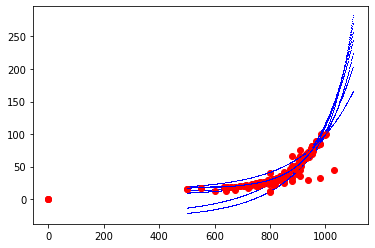

In [7]:
%matplotlib inline

plt.figure(dpi=1000)

for expt_key in filtered_database['Experiments']:
    print(f"\n{expt_key}") ## DEBUG
    filtered_database['Experiments'][expt_key]['Curve_models'] = []
#     plt.figure() # comment out to plot all on one figure
    
    for curve_num, curve in enumerate(filtered_database['Experiments'][expt_key]['Curves']):
        print(f"Curve: {curve_num+1}") ## DEBUG
        measured_T = curve['data'].iloc[:,0]
        measured_volfracbeta = curve['data'].iloc[:,1]

        try:
            param, param_cov = curve_fit(testfunc, measured_T, measured_volfracbeta)
            print(f"a:{param[0]}\tb:{param[1]}\tc: {param[2]}\td: {param[3]}") ## DEBUG
        except:
            print(f"An exponential growth function could not be fit to {expt_key}.")
            plt.plot(0, 0, 'o', color ='red',
#                      label =f"{expt_key} dataset[{curve_num+1}]",
                     label =f"Datapoints",
                    )
            pass
        
        T_linspace = np.arange(500,1000, 1)
        fit_volfracbeta = param[0] + param[1]**( param[2]*(T_linspace+param[3]) )
        if 100 in np.around(fit_volfracbeta):
            beta_transus = T_linspace[ np.where(np.around(fit_volfracbeta)==100)[0] ]
            print(f"Found beta transus!: T={beta_transus[0]}C")
        extrapolated_data = {
                "T_linspace": T_linspace,
                "fit_volfracbeta": fit_volfracbeta
               }
        filtered_database['Experiments'][expt_key]['Curve_models'].append(pd.DataFrame(extrapolated_data))
        
        modelT = filtered_database['Experiments'][expt_key]['Curve_models'][curve_num].iloc[:,0]
        modelbetafrac = filtered_database['Experiments'][expt_key]['Curve_models'][curve_num].iloc[:,1]
 
        plt.figure() # comment out to plot all on one figure
        plt.plot(measured_T, measured_volfracbeta, 'o', color ='red',
#                  label =f"{expt_key} dataset[{curve_num+1}]", # for ind curve plots
                 label =f"Datapoints", # for plot alltogther
                )
        plt.plot(modelT, modelbetafrac, ',', color ='blue',
#                  label =f"{expt_key}_model[{curve_num+1}]",
                 label =f"Model Curves",
                )   

for paper_key in filtered_database['Papers']:
    print(f"\n{paper_key}") ## DEBUG
    filtered_database['Papers'][paper_key]['Curve_models'] = []
#     plt.figure() # comment out to plot all on one figure
    
    for curve_num, curve in enumerate(filtered_database['Papers'][paper_key]['Curves']):
        print(f"Curve: {curve_num+1}") ## DEBUG
        T = curve['data'].iloc[:,0]
        volfracbeta = curve['data'].iloc[:,1]

        try:
            param, param_cov = curve_fit(testfunc, T, volfracbeta)
            print(f"a:{param[0]}\tb:{param[1]}\tc: {param[2]}\td: {param[3]}") ## DEBUG
        except:
            print(f"An exponential growth function could not be fit to {paper_key}.")
            plt.plot(0, 0, 'o', color ='red',
#                      label =f"{paper_key} dataset[{curve_num+1}]",
                     label =f"Datapoints",
                    )
            pass
        
        T_linspace = np.arange(500,1100, 1)
        fit_volfracbeta = param[0] + param[1]**( param[2]*(T_linspace+param[3]) )
        if 100 in np.around(fit_volfracbeta):
            beta_transus = T_linspace[ np.where(np.around(fit_volfracbeta)==100)[0] ]
            print(f"Found beta transus!: T={beta_transus[0]}C")
        extrapolated_data = {
                "T_linspace": T_linspace,
                "fit_volfracbeta": fit_volfracbeta
               }
        filtered_database['Papers'][paper_key]['Curve_models'].append(pd.DataFrame(extrapolated_data))
        
        modelT = filtered_database['Papers'][paper_key]['Curve_models'][curve_num].iloc[:,0]
        modelbetafrac = filtered_database['Papers'][paper_key]['Curve_models'][curve_num].iloc[:,1]
 
        plt.plot(T, volfracbeta, 'o', color ='red',
#                  label =f"{paper_key} dataset[{curve_num+1}]", # for ind curve plots
                 label =f"Datapoints", # for plot alltogther
                )
        plt.plot(modelT, modelbetafrac, ',', color ='blue',
#                  label =f"{paper_key}_model[{curve_num+1}]", # for ind source
                 label =f"Model Curves", # for plot alltogether
                )
    
# mean betavolfrac coloumn over all dataframes
mean_rows = []
for rows in zip(*[df.iloc[:, 1] for df in list_of_dataframes]):
    mean_row = sum(rows) / len(rows)
    mean_rows.append(mean_row)
# Create a DataFrame from the calculated mean rows of betavolfrac

T = pd.DataFrame(np.linspace(500, 1000, len(mean_rows)))
mean_beta_volfrac = pd.DataFrame(mean_rows)
mean_betaapproach_curve = pd.concat([T, mean_beta_volfrac], axis=1)

plt.plot(mean_betaapproach_curve['data'].iloc[:,0], mean_betaapproach_curve['data'].iloc[:,1],
         color='k', linewidth=5,
         label='Mean model beta approach curve')

plt.title('Beta approach curves of Ti64')
plt.xlabel(f"Temperature [C]")
plt.xlim(490, 1010)
plt.ylabel(f"% Vol frac β")
plt.ylim(0, 100)
plt.yticks([0,10,20,30,40,50,60,70,80,90,100],
           ["0%","10%","20%","30%","40%","50%","60%","70%","80%","90%","100%"])
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.grid()

With this mean curve of models of all datasets, we can return an answer for beta volume fraction \% given an input temperature T:


In [8]:
input_T = 900

mean_model_T = mean_betaapproach_curve['data'].iloc[:,0]
mean_model_betavolfrac = mean_betaapproach_curve['data'].iloc[:,1]

if 100 in np.around(mean_model_betavolfrac):
    beta_transus = mean_model_T[ np.where(np.around(mean_model_betavolfrac)==100)[0] ]
    print(f"\nBeta Transus: T={beta_transus.iloc[0]}C")

T_idx = np.where(round(mean_betaapproach_curve['data'].iloc[:,0])==input_T)[0]
beta_volfrac = mean_betaapproach_curve['data'].iloc[T_idx, 1].iloc[0]
print(f"\nBeta volume fraction at T={input_T} is {beta_volfrac}%")

NameError: name 'mean_betaapproach_curve' is not defined